Hello, welcome to the example of how to use the glaciome model. 
I mostly run this via terminal, but I will python's 'os.system' and 'subprocess' to accomplish this from this notebook.
It is critical that you have the correct conda environment. See the attached .yml file for this. 

PACE is GA Tech's HPC, PAX is Tufts HPC (I call it this at least). 

In [1]:
import os
import subprocess
import time
import fileinput
import sys
# Edits files in place, used for adjusting MITgcm files
def replaceAll(file,searchExp,replaceExp):
    for line in fileinput.input(file, inplace=1):
        if searchExp in line:
            line = line.replace(searchExp,replaceExp)
        sys.stdout.write(line)

os.system('pwd')

/Users/psummers8/Documents/MITgcm/MITgcm


0

The first thing we will do is move to 'elizaScripts' where there is a configuration file 'belugaModel.py'. You can edit specifics about this configuration from within this file, but for now it is configured to run a small, MPI run that will work on a mac computer (if you have MPI configured). This will also work on PACE/PAX, as the script is aware of where it is being run. IF PACE or PAX update their working directory naming schemes this could break, see notes there for how to update this. 

Once you are satified with the model run and name, execute this python script. This will make a new folder in the 'experiments' directory with the needed files. You MUST execute this file from inside the 'elizaScript' directory.

In [2]:
os.chdir('elizaScripts')
os.system('pwd')

/Users/psummers8/Documents/MITgcm/MITgcm/elizaScripts


0

This script will ask you to confirm the set up and description. These will be recorded in a 'input/buildScript.py' and 'input/setupReport.txt' so you can remember what happened here when you come back to it later. Make good notes! You will simply call the method as 'python belugaModel.py' and then press enter, and then enter again after the prompt asks you confirm. If you don't like the scriptio, ctrl-c will kill the script and you can adjust it. 

Running this script will overwrite existing files/experiments, so be careful, you cannot undo this. 

The output is very long, and basically tells you everythig that is happening as it goes. Feel free to read the comments in that script to make more sense of it all. If you call this on a mac, matplotlib figures will pop up and must be dismissed to continue. These are also saved as PNGs in input/ for later viewing. 

In [3]:
process = subprocess.Popen(['python', 'belugaModel.py'], stdin=subprocess.PIPE, text=True)
time.sleep(2)

process.communicate(input='\n')

System identified as Darwin
====== Welcome to the mélange building script =====
Coupling MITgcm and Melange1D
Allows for seasonal forcing (plume and off shore)
Enables pTracers for plume and icebergs seperately

big pool model, 20km pool off shore
ramping summer peak from 500 to 1500
Coupled with variable Uc and 4x enhanced melt
Summer forcing

If this is a pickup, 
Copying MITgcmPickup/iceberg/GLACIOME files from pickup_location is automatic

Directory: example 
	makeDirs: True, writeFiles: True, pickup: None
Confirm above is accurate before continuing...run_config is {'ncpus_xy': [4, 2], 'run_name': 'example', 'ndays': 1, 'test': False, 'horiz_res_m': 700, 'Lx_m': 70000, 'Ly_m': 11200, 'make_icebergs': True, 'pickup_location': None, 'use_GMRedi': False, 'periodic_forcing': True, 'use_MPI': True, 'lf': '\r\n', 'exps_dir': '/Users/psummers8/Documents/MITgcm/MITgcm/experiments', 'run_dir': '/Users/psummers8/Documents/MITgcm/MITgcm/experiments/example'}
run directory and subdirectories:


/Users/psummers8/Documents/MITgcm/MITgcm/elizaScripts/belugaModel.py:1272: RuntimeWarning: Mean of empty slice
  pc = plt.pcolormesh(x[0,:],-sum_z,np.nanmean(varphi,axis=1),cmap='gray_r')
/Users/psummers8/anaconda3/envs/MITgcm/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1216: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a, func=_nanmedian, keepdims=keepdims,


(None, None)

In [4]:
#this will stop the above to release us to do other runs
process.terminate()

Now, you can navigate to the new run folder

In [5]:
os.system('pwd')
os.chdir('../experiments/example')
os.system('pwd')

/Users/psummers8/Documents/MITgcm/MITgcm/elizaScripts
/Users/psummers8/Documents/MITgcm/MITgcm/experiments/example


0

Now we have a wonderful run folder here. If you are on HPC, you may want to move this to scratch, or another large storage location. For this example we will not do that. All symlinks within this folder are full file paths, so can support moving anywhere you would like to go. Once in the final desination, you move into the run folder (where we are now). 

Next up is building the MITgcm code, as fortran is compiled. There are different versions for each system (PACE/PAX/Mac) so you must build on the system you intend to run it on. The building script again is smart and knows where it is being built. This again depends on the directory names as the root of PACE/PAX.

This is a bash script. You must point the script to the location of the MITgcm folder (relative or full path names both work), as well as include the option -mpi flag if this is a mpi run. You must call this script from the run folder. If you go to MITgcm.com and look at their documentation, this script is automating lots of the fun stuff required to make this go. My script is really just a little wrapper for their method genmake2. 

For what ever reason I can't make this work from this notebook, so navigate to this folder in a terminal, activate the proper conada env, and execute:
```bash ../makeBuild.sh ../../.. -mpi```

This will have a ton of outputs, you can ignore warnings, but errors mean something is wrong with you compiler (likely) or the MITgcm code if you changed it (more likely)

The preamble has the script clarify what machine it thinks it is running on, and clarified what building script it is using and where it is building. The FC_CHECK should be 5/5, but sometime 3/5 of is fine, 0/5 of means it will fail and you have a bad version of fortran/MPI enabled.  
```
Idenitfied machine as Mac
File Makefile exists, cleaning
rm -rf *.p *.fr9 *.mod  work.{pc,pcl} *.template
rm -rf *.o
rm -rf *.for
rm -rf *.ffr9  ad_input*
find . -type l -exec rm {} \;
rm -rf *.flowdir
rm -f PACKAGES_CONFIG.h AD_CONFIG.h FC_NAMEMANGLE.h BUILD_INFO.h f90mkdepend.log Makefile.old
rm -f taf_command taf_output taf_ad.log taf_ad_flow.log taf_ftl.log
====== Building with MPI and darwin_amd64_gfortran at /Users/psummers8/Documents/MITgcm/MITgcm/experiments/Example/build =====

GENMAKE :

A program for GENerating MAKEfiles for the MITgcm project.
   For a quick list of options, use "genmake2 -h"
or for more detail see the documentation, section "Building the model"
   (under "Getting Started") at:  https://mitgcm.readthedocs.io/

===  Processing options files and arguments  ===
  getting local config information:  none found
  getting OPTFILE information:
    using OPTFILE="../../../tools/build_options/darwin_amd64_gfortran"
    get Compiler-version: '15'
../../../tools/build_options/darwin_amd64_gfortran: line 119: nf-config: command not found
  getting AD_OPTFILE information:
    using AD_OPTFILE="../../../tools/adjoint_options/adjoint_default"
  check Fortran Compiler...  pass  (set FC_CHECK=5/5)
  check makedepend (local: 0, system: 1, 1)
  Turning on MPI cpp macros
```

The end of the output should read:

```
Warning: 'psnorm' may be used uninitialized [-Wmaybe-uninitialized]
ini_p_ground.for:3307:15:

 3307 |       Real*8  psNorm, rMidKp1
      |               ^~~~~~
note: 'psnorm' was declared here
port_rand.for:157:72:

  157 |       port_rand_norm = t*x1
      |                                                                        ^
Warning: 'x1' may be used uninitialized [-Wmaybe-uninitialized]
port_rand.for:140:14:

  140 |       real*8 x1, x2, xs, t
      |              ^~
note: 'x1' was declared here
Creating mitgcmuv ...
ld: warning: duplicate -rpath '/Users/psummers8/anaconda3/envs/demo/lib' ignored
ld: warning: duplicate -rpath '/Users/psummers8/anaconda3/envs/demo/lib' ignored
(⌐■_■) Done building
```

Importantly, ```Creating mitgcmuv``` and the glasses man ```(⌐■_■)``` mean it worked. It also makes a fun noise on Mac, so don't let that surprise you. 

Wondeful, now you're almost ready. The melange script uses ```melangeModel.py``` to control factors of the run. 'frestStart' assumes a fresh start, but setting this to false lets the job pick up any existing run and continue running for `iteratationsToRun' more days. For now we will change from the default to 5 days.


 (DO THIS YOURSELF NOW IN A TEXT EDITOR)

Now we are ready to go! To run the model we just call ```RunModelMpi.py```. This again detects what machine it is run on and request the approriate number of cores for MPI. This usually has no or very little output while MITgcm is running. To monitor the MITgcm run you should look at ```results/STDOUT.0001```, there is one for each core running. End notifications can have warnings, generally that is OK so long as no NaNs pop up. Underflow errors I think are that the tracers are initialized as 0 everywhere, so at the start they are below numeric precision. The mélange script updates you on how things are going with the mélange. This is also saved to ```couplingResults/out.txt```. Mélange files are the ```.pickle``` files in ```/couplingResults```. MITgcm files are saved as diagnoistic files in ```/results```. Read more about these on MITgcm.com. Here we have plotting scripts that rely on the exact configuration of these files. 

MPI and MITgcm tends to make many many files as there are files for each core, and this gets crazy (like millions of files) if you have many cores, and many days (years) of data. To account for this the script is cleaning up files as it goes. Noteably it delets pickups that are more than 2 iterations old (but not diagnostics). This will attempt to delete negative time pickup files for first few iterations, this is OK. Other errors are worth investigating. 

The script also reduces these 'tile' files to 'global' files which massively reduces file counts:
```
condensing diagnostic tiles files to global files iter:23040
		 == BRGFlx ==
		 == dynDiag ==
		 == ptraceDiag ==
		 == plumeDiag ==
```
So that is what those updates are telling you. If you edit which files are made, this part might fail if it tried to edit files that aren't there. You can easily edit the list of files it looks for from the ```MakeRunMpi.py``` script.

If you are running this on PAX or PACE, a ```submitBatch.sh``` file should be auto generated for you within the run directory, (double check the email is right). To call this you simply need to run:
```sbatch submitBatch.sh```

In [ ]:
#The -u flag lets it write output directly and need to wait, 'unbuffered' is the flag.
os.system('python -u RunModelMpi.py') #On my mac this take about 8-10 minutes. On activity monitor or htop you should see 8 mitgcmuv tasks running their little hearts out. 
#This is moderately to devistatingly impactful on the performacnce of your computer


Operating system identified as Darwin
Identified cores as 4.0 x 2.0 = 8.0
Running from fresh start...
Assuming fresh MITgcm directory. Steps to run: 5...


Note: The following floating-point exceptions are signalling: IEEE_UNDERFLOW_FLAG
STOP NORMAL END
Note: The following floating-point exceptions are signalling: IEEE_UNDERFLOW_FLAG
STOP NORMAL END
Note: The following floating-point exceptions are signalling: IEEE_UNDERFLOW_FLAG
STOP NORMAL END
Note: The following floating-point exceptions are signalling: IEEE_UNDERFLOW_FLAG
STOP NORMAL END
Note: The following floating-point exceptions are signalling: IEEE_UNDERFLOW_FLAG
STOP NORMAL END
Note: The following floating-point exceptions are signalling: IEEE_UNDERFLOW_FLAG
STOP NORMAL END
Note: The following floating-point exceptions are signalling: IEEE_UNDERFLOW_FLAG
STOP NORMAL END
Note: The following floating-point exceptions are signalling: IEEE_UNDERFLOW_FLAG
STOP NORMAL END


		 == BRGFlx ==
		 == dynDiag ==
		 == ptraceDiag ==
		 == plumeDiag ==
=== GLACIOME Running, load MITgcm data from end of day 1.00, using melange index 00000 === 
	Melt Rates min/mean/max: -0.31, -0.20, -0.18 [m/day]:
	Previous Length: 20953.945, H0: 171.406
	New      Length: 21003.952, H0: 171.495, ∆L: 50.007, ∆H0: 0.089
	term loc/depth     0/600.0 m, calving/glacier speed: 6000/6000 m/yr
		Seconds to run GLACIOME step: 1.6526
	Saved as MITgcmRun_00001.pickle
	Prepping MITgcm for day 2.00
	adjust start iteration 0 to 5760
	adjust end time 86400 to 172800


rm: results/pick*.-000011520.*: No such file or directory
Note: The following floating-point exceptions are signalling: IEEE_UNDERFLOW_FLAG
STOP NORMAL END
Note: The following floating-point exceptions are signalling: IEEE_UNDERFLOW_FLAG
STOP NORMAL END
Note: The following floating-point exceptions are signalling: IEEE_UNDERFLOW_FLAG
STOP NORMAL END
Note: The following floating-point exceptions are signalling: IEEE_UNDERFLOW_FLAG
STOP NORMAL END
Note: The following floating-point exceptions are signalling: IEEE_UNDERFLOW_FLAG
STOP NORMAL END
Note: The following floating-point exceptions are signalling: IEEE_UNDERFLOW_FLAG
STOP NORMAL END
Note: The following floating-point exceptions are signalling: IEEE_UNDERFLOW_FLAG
STOP NORMAL END
Note: The following floating-point exceptions are signalling: IEEE_UNDERFLOW_FLAG
STOP NORMAL END


	condensing diagnostic tiles files to global files iter:11520
		 == BRGFlx ==
		 == dynDiag ==
		 == ptraceDiag ==
		 == plumeDiag ==
		Seconds to run coupled step: 92.5353
=== GLACIOME Running, load MITgcm data from end of day 2.00, using melange index 00001 === 
	Melt Rates min/mean/max: -3.74, -0.42, -0.12 [m/day]:
	Previous Length: 21003.952, H0: 171.495
	New      Length: 21057.509, H0: 170.070, ∆L: 53.558, ∆H0: -1.426
	term loc/depth     0/600.0 m, calving/glacier speed: 6000/6000 m/yr
		Seconds to run GLACIOME step: 2.0952
	Saved as MITgcmRun_00002.pickle
	Prepping MITgcm for day 3.00
	adjust start iteration 5760 to 11520
	adjust end time 172800 to 259200


...

Note: The following floating-point exceptions are signalling: IEEE_UNDERFLOW_FLAG
STOP NORMAL END
Note: The following floating-point exceptions are signalling: IEEE_UNDERFLOW_FLAG
STOP NORMAL END
Note: The following floating-point exceptions are signalling: IEEE_UNDERFLOW_FLAG
STOP NORMAL END
Note: The following floating-point exceptions are signalling: IEEE_UNDERFLOW_FLAG
STOP NORMAL END
Note: The following floating-point exceptions are signalling: IEEE_UNDERFLOW_FLAG
STOP NORMAL END
Note: The following floating-point exceptions are signalling: IEEE_UNDERFLOW_FLAG
STOP NORMAL END
Note: The following floating-point exceptions are signalling: IEEE_UNDERFLOW_FLAG
STOP NORMAL END
Note: The following floating-point exceptions are signalling: IEEE_UNDERFLOW_FLAG
STOP NORMAL END


	condensing diagnostic tiles files to global files iter:28800
		 == BRGFlx ==
		 == dynDiag ==
		 == ptraceDiag ==
		 == plumeDiag ==
		Seconds to run coupled step: 92.1874
=== GLACIOME Running, load MITgcm data from end of day 5.00, using melange index 00004 === 
	Melt Rates min/mean/max: -5.59, -0.56, -0.06 [m/day]:
	Previous Length: 21153.685, H0: 168.289
	New      Length: 21201.715, H0: 166.702, ∆L: 48.030, ∆H0: -1.587
	term loc/depth     0/600.0 m, calving/glacier speed: 6000/6000 m/yr
		Seconds to run GLACIOME step: 2.0393
	Saved as MITgcmRun_00005.pickle
	Prepping MITgcm for day 6.00
	adjust start iteration 23040 to 28800
	adjust end time 432000 to 518400


Note: The following floating-point exceptions are signalling: IEEE_UNDERFLOW_FLAG
STOP NORMAL END
Note: The following floating-point exceptions are signalling: IEEE_UNDERFLOW_FLAG
STOP NORMAL END
Note: The following floating-point exceptions are signalling: IEEE_UNDERFLOW_FLAG
STOP NORMAL END
Note: The following floating-point exceptions are signalling: IEEE_UNDERFLOW_FLAG
STOP NORMAL END
Note: The following floating-point exceptions are signalling: IEEE_UNDERFLOW_FLAG
STOP NORMAL END
Note: The following floating-point exceptions are signalling: IEEE_UNDERFLOW_FLAG
STOP NORMAL END
Note: The following floating-point exceptions are signalling: IEEE_UNDERFLOW_FLAG
STOP NORMAL END
Note: The following floating-point exceptions are signalling: IEEE_UNDERFLOW_FLAG
STOP NORMAL END


	condensing diagnostic tiles files to global files iter:34560
		 == BRGFlx ==
		 == dynDiag ==
		 == ptraceDiag ==
		 == plumeDiag ==
		Seconds to run coupled step: 96.3625
	condensing grid tile files to global files
		== Depth ==
		== DXC ==
		== DXF ==
		== DXG ==
		== DXV ==
		== DYC ==
		== DYF ==
		== DYG ==
		== DYU ==
		== hFacC ==
		== hFacS ==
		== hFacW ==
		== maskInC ==
		== maskInS ==
		== maskInW ==
		== RAC ==
		== RAS ==
		== RAW ==
		== RAZ ==
		== XC ==
		== XG ==
		== YC ==
		== YG ==


0

For plotting you can use the scripts ```giflook...py``` which have help hint if you use the ```-h``` flag. These must be called from the run folder, but they live in the ```analysis``` folder, though there are symlinks in ```experiments``` for convenience. This make gifs which don't show up on this notebook, but you can see them in the ```figs``` folder.
Colors are controlled by the files ```input/plotHelper.py```.

In [8]:
os.system('python ../giflookSideAvg.py -h')
os.system('python ../giflookSideAvg.py -s') # -s for shadow which is how I show iceberg fraction in an overlay

usage: giflookSideAvg.py [-h] [-q] [-k [KVALUES ...]] [-n [NUMFRAMES]]
                         [-t TIMERANGE TIMERANGE] [-s] [-xl [XLIMIT]]
                         [-dpi [DPI]]

Plot dynamics width averaged

options:
  -h, --help            show this help message and exit
  -q, --quick           quick option for last from only, double to show
                        plot(s)
  -k [KVALUES ...], --kValues [KVALUES ...]
                        option specification of views to plot [default = all]
  -n [NUMFRAMES], --numFrames [NUMFRAMES]
                        optional specification of numFrames [default = 60]
  -t TIMERANGE TIMERANGE, --timeRange TIMERANGE TIMERANGE
                        optional specification of start and endtime in DAYS
                        [default = Full Range]
  -s, --shadow          option of shadow for mélange [default (off)]
  -xl [XLIMIT], --xlimit [XLIMIT]
                        optional max x [default = entire frame]
  -dpi [DPI], --dpi [DPI]
        

0

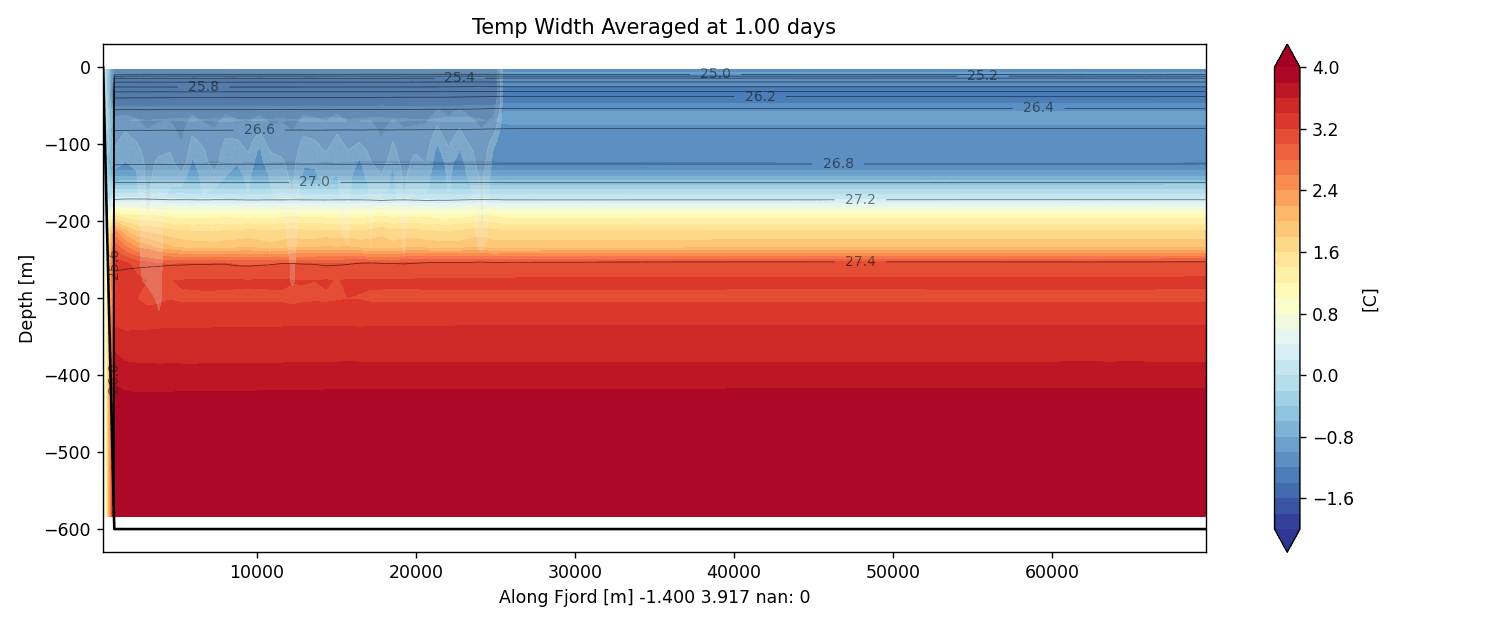

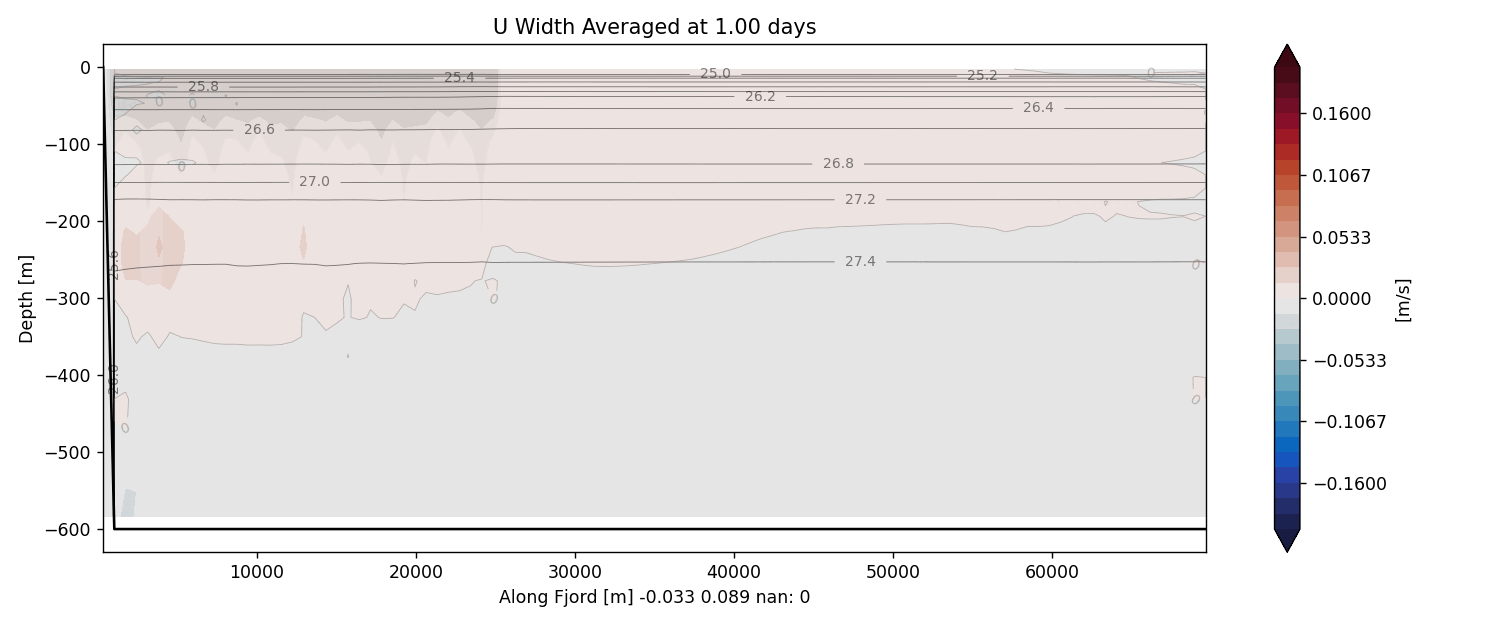

In [10]:
from IPython.display import Image, display

# For a local file in your working directory
display(Image(filename="figs/sideAvg_Temp.gif"))
display(Image(filename="figs/sideAvg_U.gif"))
